# Importar librerías

In [2]:
# Librerías para cargar y manipular datos
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import ks_2samp

# Librerías para visualización
from matplotlib import pyplot as plt
import seaborn as sns

# Cargar recursos

Se cargan los resultados de la primera fase de experimentación de los modelos. Se cargan 2 tipos de resultados:

1. Los que tienen que ver con la validación para elegir el threshold adecuado para la detección de anomalías

2. Los que tienen que ver con el entrenamiento para monitorizar que este se ha ejecutado de forma correcta y corroborar el threshold elegido

In [3]:
# Directorio donde se encuentran los resultados de las ejecuciones de los experimentos
OUTPUT_FOLDER = Path("../../outputs/runs")

## Carga de los recursos de LOF por dispositivo

In [4]:
# Directorio donde se encuentran los resultados de la experimentación de los modelos LOF por dispositivo
LOF_OUTPUT_FOLDER = OUTPUT_FOLDER / "nbaiot_lof_per_device_stage_1" / "devices"

In [5]:
# Rutas de los archivos de scores de validación
LOF_DEVICE_1_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_1" / "val_scores.parquet"
LOF_DEVICE_2_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_2" / "val_scores.parquet"
LOF_DEVICE_3_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_3" / "val_scores.parquet"
LOF_DEVICE_4_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_4" / "val_scores.parquet"
LOF_DEVICE_5_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_5" / "val_scores.parquet"
LOF_DEVICE_6_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_6" / "val_scores.parquet"
LOF_DEVICE_7_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_7" / "val_scores.parquet"
LOF_DEVICE_8_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_8" / "val_scores.parquet"
LOF_DEVICE_9_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_9" / "val_scores.parquet"

# Rutas de los archivos de scores de entrenamiento
LOF_DEVICE_1_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_1" / "train_scores.parquet"
LOF_DEVICE_2_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_2" / "train_scores.parquet"
LOF_DEVICE_3_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_3" / "train_scores.parquet"
LOF_DEVICE_4_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_4" / "train_scores.parquet"
LOF_DEVICE_5_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_5" / "train_scores.parquet"
LOF_DEVICE_6_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_6" / "train_scores.parquet"
LOF_DEVICE_7_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_7" / "train_scores.parquet"
LOF_DEVICE_8_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_8" / "train_scores.parquet"
LOF_DEVICE_9_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_9" / "train_scores.parquet"

In [6]:
# Dataframes para almacenar los scores de validación
lof_train_scores_df = pd.concat(
    [
        pd.read_parquet(LOF_DEVICE_1_TRAIN_SCORES_PATH).assign(device=1),
        pd.read_parquet(LOF_DEVICE_2_TRAIN_SCORES_PATH).assign(device=2),
        pd.read_parquet(LOF_DEVICE_3_TRAIN_SCORES_PATH).assign(device=3),
        pd.read_parquet(LOF_DEVICE_4_TRAIN_SCORES_PATH).assign(device=4),
        pd.read_parquet(LOF_DEVICE_5_TRAIN_SCORES_PATH).assign(device=5),
        pd.read_parquet(LOF_DEVICE_6_TRAIN_SCORES_PATH).assign(device=6),
        pd.read_parquet(LOF_DEVICE_7_TRAIN_SCORES_PATH).assign(device=7),
        pd.read_parquet(LOF_DEVICE_8_TRAIN_SCORES_PATH).assign(device=8),
        pd.read_parquet(LOF_DEVICE_9_TRAIN_SCORES_PATH).assign(device=9),
    ],
    ignore_index=True,
)

In [7]:
# Dataframes para almacenar los scores de entrenamiento
lof_val_scores_df = pd.concat(
    [
        pd.read_parquet(LOF_DEVICE_1_VAL_SCORES_PATH).assign(device=1),
        pd.read_parquet(LOF_DEVICE_2_VAL_SCORES_PATH).assign(device=2),
        pd.read_parquet(LOF_DEVICE_3_VAL_SCORES_PATH).assign(device=3),
        pd.read_parquet(LOF_DEVICE_4_VAL_SCORES_PATH).assign(device=4),
        pd.read_parquet(LOF_DEVICE_5_VAL_SCORES_PATH).assign(device=5),
        pd.read_parquet(LOF_DEVICE_6_VAL_SCORES_PATH).assign(device=6),
        pd.read_parquet(LOF_DEVICE_7_VAL_SCORES_PATH).assign(device=7),
        pd.read_parquet(LOF_DEVICE_8_VAL_SCORES_PATH).assign(device=8),
        pd.read_parquet(LOF_DEVICE_9_VAL_SCORES_PATH).assign(device=9),
    ],
    ignore_index=True,
)

# Estudio del *threshold* de LOF (*Local Outlier Factor*) por dispositivo

## 1. Caracterización de los *anomaly scores*

El primer paso del estudio consiste en analizar la distribución de los *anomaly scores* generados por los modelos LOF entrenados para cada dispositivo. Dado que cada modelo se ha entrenado únicamente con tráfico benigno, estos *scores* representan la respuesta del detector ante comportamiento considerado normal.

Este análisis tiene 2 objetivos principales:

1. Permite estudiar la forma de la distribución de *scores* benignos para cada dispositivo. 

2. Permite comparar el comportamiento observado en entrenamiento y validación. Esta comparación es importante porque el umbral de anomalía se seleccionará a partir del conjunto de validación, por lo que resulta necesario comprobar que la distribución de *scores* en validación es coherente con la observada durante el entrenamiento.

Para ello, se emplean gráficos combinados de tipo *violinplot* y *boxplot*. El *violinplot* permite visualizar la forma global de la distribución, mientras que el *boxplot* resume su tendencia central, dispersión intercuartílica y valores extremos. Además, se complementa el análisis visual con el test de Kolmogorov-Smirnov, que permite cuantificar si las distribuciones de entrenamiento y validación presentan diferencias estadísticamente significativas.

In [17]:
# Juntamos los dataframes de scores de entrenamiento y validación para poder graficarlos juntos
lof_train_plot_df = lof_train_scores_df.copy()
lof_train_plot_df["split"] = "Entrenamiento"

lof_val_plot_df = lof_val_scores_df.copy()
lof_val_plot_df["split"] = "Validación"

lof_scores_plot_df = pd.concat(
    [lof_train_plot_df, lof_val_plot_df],
    ignore_index=True,
)

lof_scores_plot_df["split"] = pd.Categorical(
    lof_scores_plot_df["split"],
    categories=["Entrenamiento", "Validación"],
    ordered=True,
)

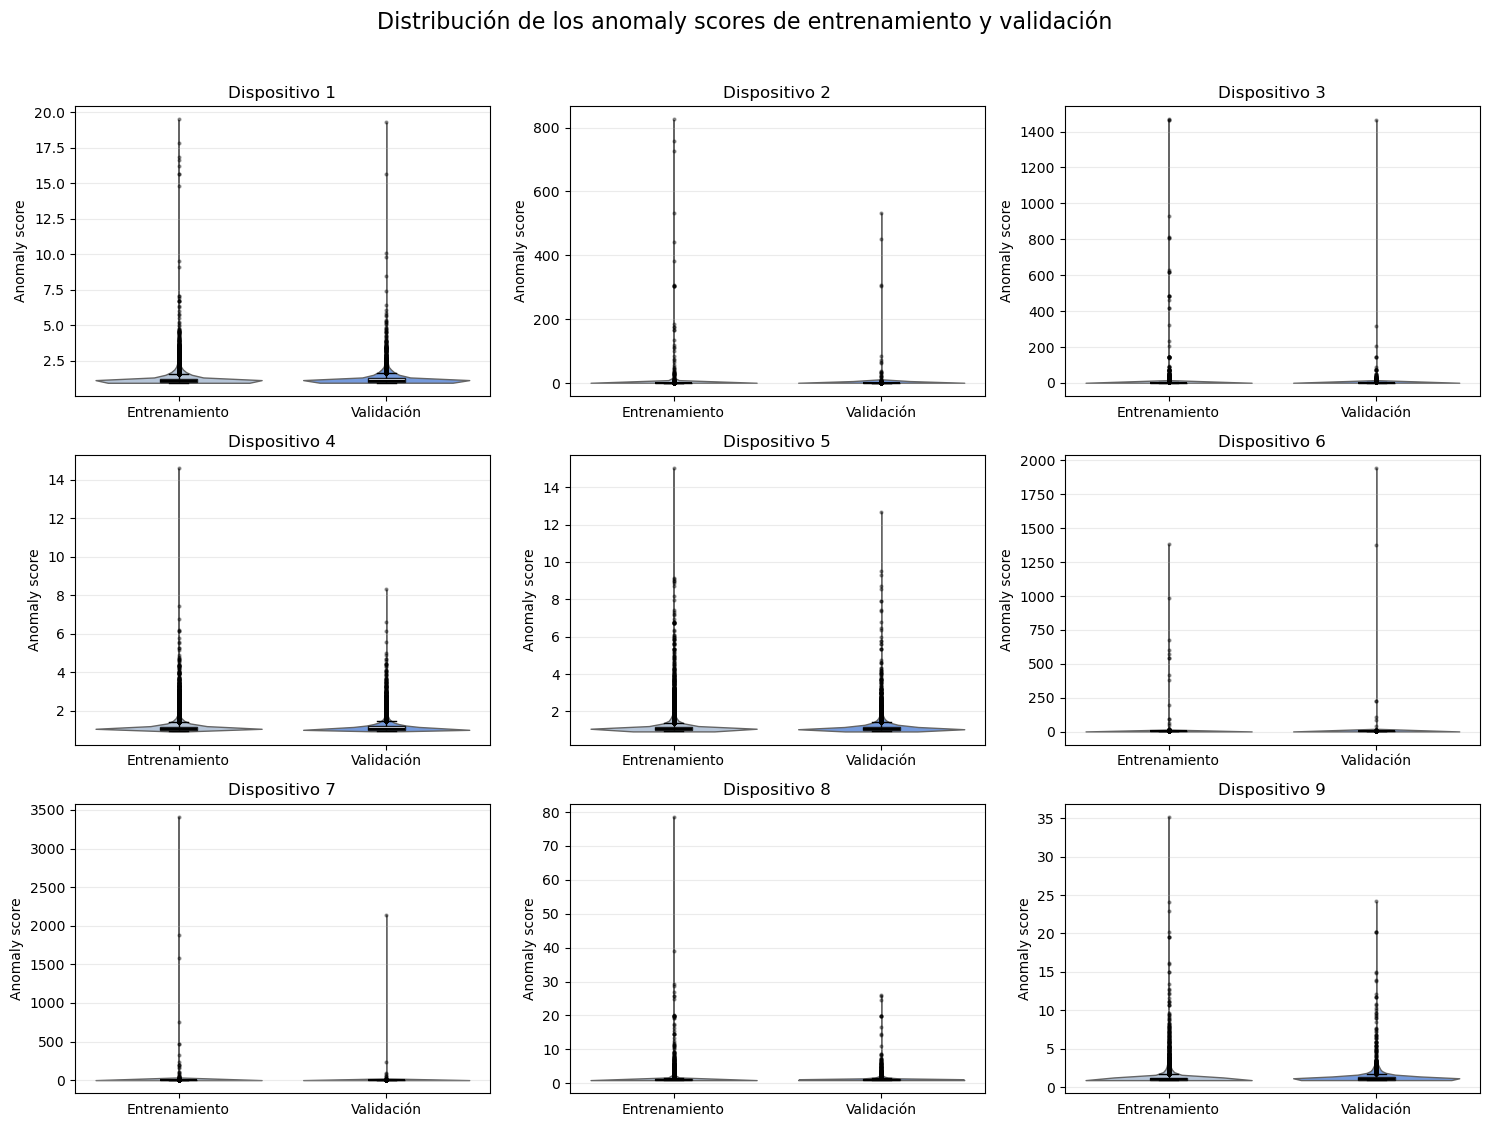

In [19]:
split_palette = {
    "Entrenamiento": "lightsteelblue",
    "Validación": "cornflowerblue",
}

fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharey=False)
for ax, device_id in zip(axes.flatten(), range(1, 10)):
    device_scores_df = lof_scores_plot_df[
        lof_scores_plot_df["device"] == device_id
    ]

    sns.violinplot(
        data=device_scores_df,
        x="split",
        y="score",
        hue="split",
        palette=split_palette,
        inner=None,
        cut=0,
        linewidth=1,
        dodge=False,
        legend=False,
        ax=ax,
    )

    sns.boxplot(
        data=device_scores_df,
        x="split",
        y="score",
        width=0.18,
        showcaps=True,
        showfliers=True,
        boxprops={
            "facecolor": "white",
            "edgecolor": "black",
            "linewidth": 1,
            "alpha": 0.85,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 1,
        },
        capprops={
            "color": "black",
            "linewidth": 1,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.5,
        },
        flierprops={
            "marker": "o",
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markersize": 2,
            "alpha": 0.35,
        },
        ax=ax,
    )

    ax.set_title(f"Dispositivo {device_id}", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Anomaly score")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Distribución de los anomaly scores de entrenamiento y validación",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()
plt.show()

In [11]:
ks_results = []
for device_id in sorted(lof_scores_plot_df["device"].unique()):
    train_scores = lof_train_scores_df.loc[
        lof_train_scores_df["device"] == device_id,
        "score",
    ].to_numpy()

    val_scores = lof_val_scores_df.loc[
        lof_val_scores_df["device"] == device_id,
        "score",
    ].to_numpy()

    ks_statistic, _ = ks_2samp(train_scores, val_scores)

    ks_results.append(
        {
            "device": device_id,
            "ks_statistic": ks_statistic,
            "train_mean": np.mean(train_scores),
            "val_mean": np.mean(val_scores),
            "train_median": np.median(train_scores),
            "val_median": np.median(val_scores),
            "train_std": np.std(train_scores),
            "val_std": np.std(val_scores),
            "train_max": np.max(train_scores),
            "val_max": np.max(val_scores),
        }
    )

ks_results_df = pd.DataFrame(ks_results)

ks_results_df

,device,ks_statistic,train_mean,val_mean,train_median,val_median,train_std,val_std,train_max,val_max
0,1,0.051116,1.188421,1.213018,1.054642,1.067816,0.444373,0.483593,19.500675,19.298923
1,2,0.017299,2.283123,2.109843,1.129069,1.123314,19.926058,16.313131,825.433167,532.555969
2,3,0.007801,2.690268,2.313819,1.117313,1.120541,23.513018,17.647846,1467.077515,1464.052368
3,4,0.039327,1.138021,1.151758,1.068821,1.079707,0.228690,0.244194,14.599893,8.308540
4,5,0.050451,1.143518,1.162001,1.049523,1.062431,0.351324,0.384403,15.016881,12.683290
5,6,0.047157,1.240753,1.346563,1.041710,1.051750,9.195938,17.145969,1382.818115,1943.231445
6,7,0.055129,1.536999,1.467731,1.038446,1.049043,24.697142,21.143850,3410.726562,2142.141357
7,8,0.049909,1.187845,1.207199,1.043669,1.055102,0.906120,0.792979,78.584511,25.925137
8,9,0.052292,1.318146,1.363022,1.069679,1.087157,0.974931,1.130840,35.170509,24.164722


Las distribuciones de *anomaly scores* obtenidas para los nueve modelos LOF presentan un comportamiento muy similar entre los conjuntos de entrenamiento y validación. Esta observación se confirma tanto visualmente mediante los diagramas de violín y cajas como cuantitativamente a través del estadístico de Kolmogorov-Smirnov. En todos los dispositivos, el valor del estadístico KS es inferior a 0.06, lo que indica que las diferencias entre ambas distribuciones son reducidas. Por tanto, puede considerarse que el conjunto de validación constituye una representación adecuada del comportamiento benigno aprendido durante el entrenamiento y, en consecuencia, resulta apropiado utilizarlo para la selección del *threshold* de detección de anomalías.

Otro aspecto destacable es que las distribuciones presentan una marcada asimetría positiva. La mayor parte de las muestras benignas se concentra en torno a valores de *anomaly score* próximos a la unidad, mientras que existe un reducido número de observaciones que alcanzan valores considerablemente superiores. Esta característica se refleja tanto en la diferencia entre la media y la mediana como en la elevada desviación típica observada en algunos dispositivos, especialmente en los dispositivos 2, 3, 6 y 7, donde aparecen valores máximos superiores a 500 e incluso superiores a 3000.

La presencia de estos valores extremos resulta especialmente relevante para el estudio del *threshold*, ya que evidencia que algunas observaciones benignas reciben *anomaly scores* considerablemente superirores al resto de muestras benignas. En consecuencia, la selección del umbral no puede basarse únicamente en medidas de tendencia central, sino que deberá considerar el comportamiento de la cola de la distribución y la frecuencia con la que aparecen estos eventos extremos. Esta observación servirá de base para analizar, en los siguientes apartados, distintos criterios de selección del *threshold* adecuados para distribuciones altamente asimétricas.

## 2. Selección del criterio de *threshold*

Una vez caracterizadas las distribuciones de *anomaly scores*, el siguiente paso consiste en estudiar qué criterio resulta más adecuado para fijar el *threshold* de cada modelo LOF. El umbral se selecciona utilizando únicamente el conjunto de validación, compuesto por tráfico benigno, manteniendo así la naturaleza no supervisada de la metodología experimental.

Los resultados del apartado anterior muestran que las distribuciones de *scores* presentan una fuerte asimetría positiva y colas derechas con valores extremos. Por este motivo, no se consideran adecuados criterios basados en supuestos de normalidad, como la media más varias desviaciones típicas, ya que la media y la desviación estándar pueden verse fuertemente afectadas por observaciones extremas.

En su lugar, se analizan criterios no paramétricos y robustos, basados únicamente en la distribución empírica de los *scores* benignos de validación. Concretamente, se estudian dos familias de criterios:

- **Criterios basados en percentiles altos**, que permiten controlar explícitamente la proporción máxima esperada de muestras benignas que quedarían por encima del *threshold*.
- **Criterios basados en el rango intercuartílico**, que utilizan una medida robusta de dispersión para identificar valores alejados del cuerpo principal de la distribución.

Para cada criterio se calcula, por dispositivo, el *threshold* resultante y la tasa de falsas alarmas estimada sobre validación:

$$
\mathrm{FPR}_{\mathrm{val}}(t)=
\frac{1}{N}\sum_{i=1}^{N}\mathbf{1}(s_i>t)
$$

donde \(s_i\) representa el *anomaly score* de una muestra benigna de validación y \(N\) el número total de muestras de validación del dispositivo correspondiente.

In [37]:
# Definición de criterios para calcular los thresholds de anomalía a partir de los scores de validación
threshold_criteria = {
    "p99": lambda scores: np.percentile(scores, 99),
    "p99_5": lambda scores: np.percentile(scores, 99.5),
    "p99_9": lambda scores: np.percentile(scores, 99.9),
    "iqr_1_5": lambda scores: (
        np.percentile(scores, 75)
        + 1.5 * (np.percentile(scores, 75) - np.percentile(scores, 25))
    ),
    "iqr_3": lambda scores: (
        np.percentile(scores, 75)
        + 3.0 * (np.percentile(scores, 75) - np.percentile(scores, 25))
    ),
}

# Cálculo de thresholds y FPR para cada dispositivo y criterio de threshold
results = []
for device in sorted(lof_val_scores_df["device"].unique()):

    scores = lof_val_scores_df.loc[
        lof_val_scores_df["device"] == device,
        "score"
    ].to_numpy()

    for criterion, func in threshold_criteria.items():

        threshold = func(scores)

        results.append({
            "device": device,
            "criterion": criterion,
            "threshold": threshold,
            "fpr (%)": 100 * np.mean(scores > threshold),
        })

results_df = pd.DataFrame(results)

# Tabla de thresholds
print("Tabla de thresholds:")
display(results_df.pivot(
    index="device",
    columns="criterion",
    values="threshold",
).round(4))

# Tabla de FPR
print("Tabla de FPR:")
display(results_df.pivot(
    index="device",
    columns="criterion",
    values="fpr (%)",
).round(4))

Tabla de thresholds:


criterion,iqr_1_5,iqr_3,p99,p99_5,p99_9
device,,,,,
1,1.5862,1.9331,2.9840,3.537800,5.675600
2,1.7081,2.1208,6.2190,26.156401,305.468109
3,2.7376,3.7749,15.4133,24.458099,72.860901
4,1.4584,1.7217,2.0849,2.425200,3.566000
5,1.4403,1.6995,2.6026,3.213400,5.906700
6,1.3770,1.5994,2.4490,3.146400,7.622800
7,1.4465,1.7118,3.7893,5.642200,16.265600
8,1.4373,1.6969,3.2468,4.797400,13.249900
9,1.7636,2.2141,5.8626,9.106900,15.522900


Tabla de FPR:


criterion,iqr_1_5,iqr_3,p99,p99_5,p99_9
device,,,,,
1,10.1110,4.4097,1.0091,0.5045,0.1009
2,9.7598,5.9474,1.0294,0.5337,0.1144
3,13.1330,8.2481,1.0102,0.5115,0.1023
4,7.1302,2.6307,1.0015,0.5022,0.1027
5,8.4225,3.9981,1.0056,0.5068,0.1046
6,8.9022,4.5069,1.0049,0.5025,0.1015
7,10.3739,6.0115,1.0067,0.5081,0.1055
8,10.4433,6.1071,1.0089,0.5045,0.1073
9,10.5223,6.2980,1.0241,0.5120,0.1024


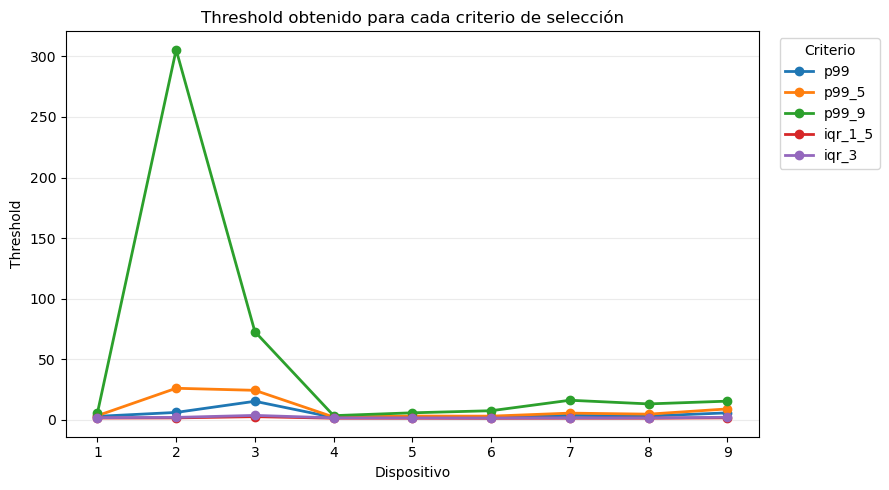

In [40]:
plt.figure(figsize=(9, 5))

for criterion in results_df["criterion"].unique():
    criterion_df = results_df[results_df["criterion"] == criterion]

    plt.plot(
        criterion_df["device"],
        criterion_df["threshold"],
        marker="o",
        linewidth=2,
        label=criterion,
    )

plt.title("Threshold obtenido para cada criterio de selección")
plt.xlabel("Dispositivo")
plt.ylabel("Threshold")
plt.xticks(range(1, 10))
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Criterio", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

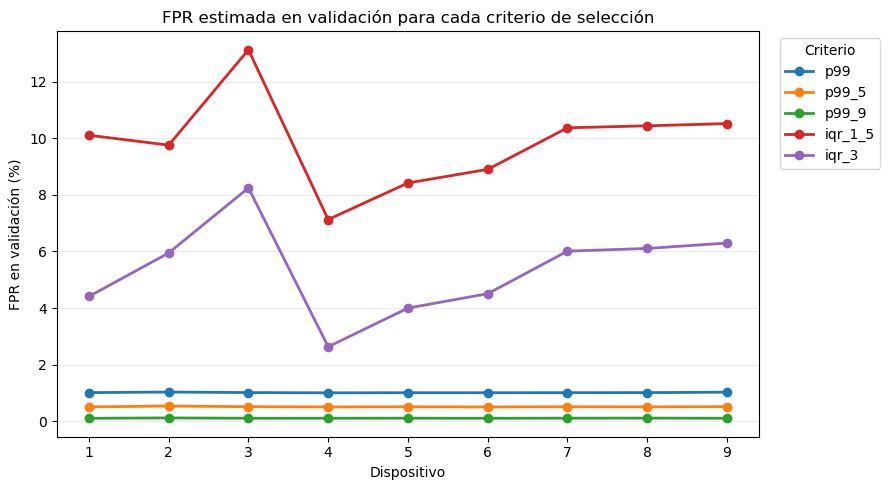

In [42]:
plt.figure(figsize=(9, 5))

for criterion in results_df["criterion"].unique():
    criterion_df = results_df[results_df["criterion"] == criterion]

    plt.plot(
        criterion_df["device"],
        criterion_df["fpr (%)"],
        marker="o",
        linewidth=2,
        label=criterion,
    )

plt.title("FPR estimada en validación para cada criterio de selección")
plt.xlabel("Dispositivo")
plt.ylabel("FPR en validación (%)")
plt.xticks(range(1, 10))
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Criterio", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Los resultados obtenidos muestran diferencias claras entre las 2 familias de criterios evaluadas. Los métodos basados en el rango intercuartílico generan thresholds relativamente próximos al cuerpo principal de la distribución, lo que se traduce en tasas de falsas alarmas considerablemente elevadas. En concreto, el criterio **IQR + 1.5** produce una FPR comprendida aproximadamente entre el 7 % y el 13 %, mientras que **IQR + 3** reduce dicha tasa hasta valores situados entre el 2.5 % y el 8 %. Aunque estos criterios son ampliamente utilizados para la detección de valores atípicos, las tasas de falsas alarmas obtenidas resultan excesivas para un sistema de detección de intrusiones, donde un elevado número de falsas alarmas dificulta su utilización práctica. Por este motivo, ambos criterios se descartan para el resto del estudio.

Por el contrario, los criterios basados en percentiles altos presentan un comportamiento significativamente más adecuado. Como era esperable, los percentiles **P99**, **P99.5** y **P99.9** permiten controlar de forma explícita la tasa máxima de falsas alarmas sobre el conjunto de validación, obteniéndose valores próximos al 1 %, 0.5 % y 0.1 %, respectivamente, en todos los dispositivos. Además, al tratarse de criterios no paramétricos, su cálculo depende únicamente de la distribución empírica de los *anomaly scores*, evitando realizar hipótesis sobre su forma, aspecto especialmente relevante dadas las distribuciones altamente asimétricas observadas en el apartado anterior.

No obstante, el análisis de los thresholds obtenidos pone de manifiesto una diferencia importante entre los tres percentiles evaluados. Mientras que los thresholds asociados a **P99** y **P99.5** evolucionan de forma relativamente gradual entre dispositivos, el criterio **P99.9** produce incrementos muy acusados en algunos de ellos, especialmente en aquellos que presentan colas de distribución más largas. Este comportamiento sugiere que dicho criterio podría depender en mayor medida de un número muy reducido de observaciones extremas presentes en la cola superior de la distribución.

A partir de estos resultados no es posible determinar todavía cuál de los tres percentiles constituye la mejor elección para definir el threshold. Sin embargo, el análisis realizado permite reducir el conjunto de candidatos a **P99**, **P99.5** y **P99.9**, descartando los criterios basados en el rango intercuartílico. En el siguiente apartado se estudiará la estabilidad de los thresholds obtenidos mediante cada uno de estos percentiles, con el objetivo de evaluar su sensibilidad frente a pequeñas variaciones en el conjunto de validación y seleccionar finalmente el criterio más robusto para todos los dispositivos.

## 3. Estabilidad de los *thresholds* seleccionados

En el apartado anterior se descartaron los criterios basados en el rango intercuartílico debido a la elevada tasa de falsas alarmas estimada sobre validación. Por tanto, en este apartado se estudia únicamente la estabilidad de los criterios basados en percentiles altos: **P99**, **P99.5** y **P99.9**.

El objetivo es analizar hasta qué punto el threshold obtenido por cada criterio depende de la muestra concreta de validación utilizada. Para ello se aplica un procedimiento de *bootstrap* sobre los *anomaly scores* de validación de cada dispositivo. En cada iteración se genera una nueva muestra con reemplazo a partir de los scores originales y se recalcula el threshold correspondiente.

Si un criterio produce thresholds muy similares entre remuestreos, puede considerarse más estable. Por el contrario, si pequeñas variaciones en la muestra de validación generan thresholds muy diferentes, el criterio será más sensible a la composición concreta de la cola de la distribución.

Dado que cada dispositivo presenta una escala distinta de *anomaly scores*, la estabilidad se compara mediante el coeficiente de variación:

$$
CV = \frac{\sigma_{\mathrm{bootstrap}}}{\mu_{\mathrm{bootstrap}}}
$$

donde $\mu_{\mathrm{bootstrap}}$ y $\sigma_{\mathrm{bootstrap}}$ representan, respectivamente, la media y la desviación típica de los thresholds obtenidos mediante bootstrap. Un menor valor de $CV$ indica una mayor estabilidad relativa del criterio.

In [51]:
N_BOOTSTRAP = 2000
RANDOM_SEED = 42

bootstrap_criteria = {
    "P99": 99,
    "P99.5": 99.5,
    "P99.9": 99.9,
}

rng = np.random.default_rng(RANDOM_SEED)

bootstrap_results = []

for device in sorted(lof_val_scores_df["device"].unique()):
    scores = lof_val_scores_df.loc[
        lof_val_scores_df["device"] == device,
        "score"
    ].to_numpy()

    n_samples = len(scores)

    for criterion, percentile in bootstrap_criteria.items():
        thresholds = []

        for _ in range(N_BOOTSTRAP):
            bootstrap_sample = rng.choice(
                scores,
                size=n_samples,
                replace=True,
            )

            thresholds.append(
                np.percentile(bootstrap_sample, percentile)
            )

        thresholds = np.array(thresholds)

        bootstrap_results.append({
            "device": device,
            "criterion": criterion,
            "mean_threshold": thresholds.mean(),
            "std_threshold": thresholds.std(ddof=1),
            "cv_threshold": thresholds.std(ddof=1) / thresholds.mean(),
            "ci_2_5": np.percentile(thresholds, 2.5),
            "ci_97_5": np.percentile(thresholds, 97.5),
        })

bootstrap_results_df = pd.DataFrame(bootstrap_results)

In [52]:
bootstrap_cv_table = (
    bootstrap_results_df
    .pivot(
        index="device",
        columns="criterion",
        values="cv_threshold",
    )
    .round(6)
)

bootstrap_cv_table

criterion,P99,P99.5,P99.9
device,,,
1,0.045787,0.037201,0.104946
2,0.407370,0.405348,0.548342
3,0.090358,0.127829,0.339074
4,0.011293,0.019652,0.033245
5,0.030005,0.045271,0.114629
6,0.022844,0.039056,0.170005
7,0.047651,0.071544,0.510896
8,0.042004,0.073878,0.326760
9,0.093157,0.126706,0.181220


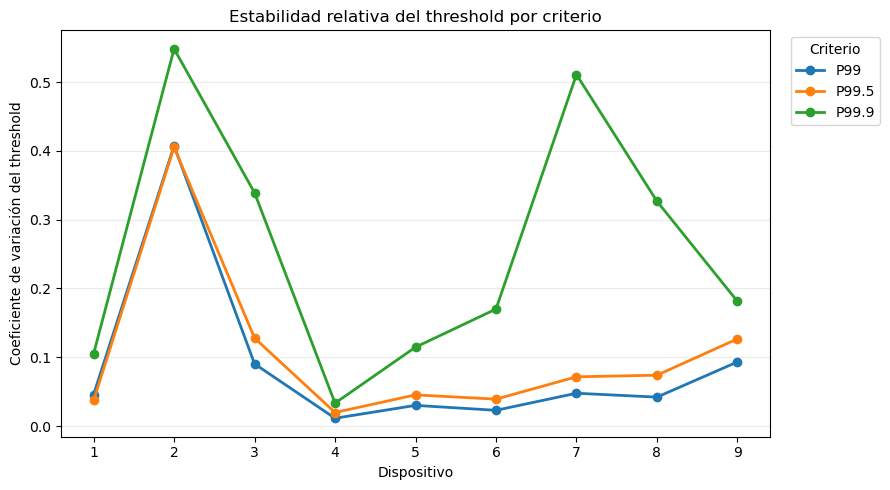

In [53]:
plt.figure(figsize=(9, 5))

for criterion in bootstrap_results_df["criterion"].unique():
    criterion_df = bootstrap_results_df[
        bootstrap_results_df["criterion"] == criterion
    ]

    plt.plot(
        criterion_df["device"],
        criterion_df["cv_threshold"],
        marker="o",
        linewidth=2,
        label=criterion,
    )

plt.title("Estabilidad relativa del threshold por criterio")
plt.xlabel("Dispositivo")
plt.ylabel("Coeficiente de variación del threshold")
plt.xticks(range(1, 10))
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Criterio", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Los resultados obtenidos mediante el procedimiento de *bootstrap* confirman la hipótesis planteada al finalizar el apartado anterior. Aunque los criterios **P99.5** y **P99.9** permiten reducir progresivamente la tasa de falsas alarmas estimada sobre el conjunto de validación, dicha reducción se consigue a costa de una menor estabilidad del threshold. En particular, el criterio **P99.9** presenta los mayores coeficientes de variación en la mayoría de los dispositivos, lo que indica una elevada sensibilidad frente a pequeñas variaciones en la composición de la muestra de validación. Este comportamiento resulta coherente con el análisis realizado en el apartado anterior, donde se observó que los thresholds asociados a este criterio dependían en gran medida de la cola extrema de la distribución de *anomaly scores*.

Por el contrario, el criterio **P99** proporciona de forma sistemática los menores coeficientes de variación en prácticamente todos los dispositivos analizados. Aunque la tasa de falsas alarmas estimada sobre validación es ligeramente superior a la obtenida mediante **P99.5** y **P99.9**, dicha diferencia es reducida (aproximadamente un 0.5 % y un 0.9 %, respectivamente), mientras que la mejora en estabilidad resulta considerable. Este comportamiento representa un mejor equilibrio entre robustez y capacidad de generalización, ya que el threshold obtenido depende en menor medida de observaciones extremas presentes en el conjunto de validación.

**Como resultado de este estudio, se selecciona el percentil P99 como criterio común para la determinación del threshold de detección de anomalías en todos los modelos LOF entrenados.** Esta decisión permite mantener una metodología homogénea para todos los dispositivos, adaptando únicamente el valor numérico del threshold a la distribución de *anomaly scores* de cada modelo.

Los thresholds finalmente seleccionados para cada dispositivo son los siguientes:

- **Dispositivo 1:** 2.9840
- **Dispositivo 2:** 6.2190
- **Dispositivo 3:** 15.4133
- **Dispositivo 4:** 2.0849
- **Dispositivo 5:** 2.6026
- **Dispositivo 6:** 2.4490
- **Dispositivo 7:** 3.7893
- **Dispositivo 8:** 3.2468
- **Dispositivo 9:** 5.8626

Con ello queda finalizada la primera fase del experimento correspondiente al entrenamiento y validación de modelos LOF específicos por dispositivo. Los thresholds obtenidos serán empleados, sin modificaciones adicionales, durante la fase de evaluación sobre el conjunto de test, donde se analizará la capacidad de detección de ataques y el comportamiento del sistema frente a datos no utilizados durante el entrenamiento ni la selección del threshold.